In [ ]:
import pandas as pd  # 导入pandas库，用于数据处理
import numpy as np   # 导入numpy库，用于数值计算
import cv2           # 导入OpenCV库，用于图像处理
import os            # 导入os库，用于与操作系统交互
import re            # 导入re库，用于正则表达式操作

from PIL import Image  # 导入PIL.Image库，用于图像读取和处理

import albumentations as A  # 导入albumentations库，用于图像增强
from albumentations.pytorch.transforms import ToTensorV2  # 导入ToTensorV2，用于将图像转换为PyTorch张量

import torch          # 导入torch库，用于深度学习模型构建和训练
import torchvision    # 导入torchvision库，包含常用的数据集和模型

# 从torchvision.models.detection.faster_rcnn导入FastRCNNPredictor类，用于修改Faster R-CNN的预测层
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# 从torchvision.models.detection导入FasterRCNN类，用于构建Faster R-CNN模型
from torchvision.models.detection import FasterRCNN
# 从torchvision.models.detection.rpn导入AnchorGenerator类，用于生成锚点
from torchvision.models.detection.rpn import AnchorGenerator

# 从torch.utils.data导入DataLoader类，用于加载数据
from torch.utils.data import DataLoader
# 从torch.utils.data导入Dataset类，用于自定义数据集
from torch.utils.data import Dataset
# 从torch.utils.data.sampler导入SequentialSampler类，用于按顺序采样数据
from torch.utils.data.sampler import SequentialSampler

# 导入matplotlib.pyplot库，用于绘图
from matplotlib import pyplot as plt

DIR_INPUT = '/kaggle/input/global-wheat-detection'  # 设置输入数据目录
DIR_TRAIN = f'{DIR_INPUT}/train'  # 设置训练数据目录
DIR_TEST = f'{DIR_INPUT}/test'    # 设置测试数据目录

DIR_WEIGHTS = '/kaggle/input/global-wheat-detection-faster-rcnn-v2/pytorch/default/1'  # 设置权重文件目录

WEIGHTS_FILE = f'{DIR_WEIGHTS}/fasterrcnn_resnet50_fpn.pth'  # 设置具体的权重文件路径


/usr/local/lib/python3.11/dist-packages/albumentations/check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
test_df = pd.read_csv(f"{DIR_INPUT}/sample_submission.csv")
test_df.shape

(10, 2)

In [ ]:
import cv2
import numpy as np
from torch.utils.data import Dataset

class WheatTestDataset(Dataset):
    # 定义一个用于测试的小麦数据集类，继承自PyTorch的Dataset类

    def __init__(self, dataframe, image_dir, transforms=None):
        # 初始化函数，接收数据框、图像目录和可选的数据增强变换作为参数
        super().__init__()

        self.image_ids = dataframe['image_id'].unique()  # 获取所有唯一的图像ID
        self.df = dataframe  # 保存数据框
        self.image_dir = image_dir  # 保存图像目录
        self.transforms = transforms  # 保存数据增强变换

    def __getitem__(self, index: int):
        # 根据索引获取数据集中的一个样本
        image_id = self.image_ids[index]  # 获取指定索引的图像ID
        records = self.df[self.df['image_id'] == image_id]  # 获取该图像ID对应的所有记录

        # 读取图像文件，使用cv2.IMREAD_COLOR模式读取彩色图像
        image = cv2.imread(f'{self.image_dir}/{image_id}.jpg', cv2.IMREAD_COLOR)
        # 将图像从BGR格式转换为RGB格式，并转换为浮点型数组
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
        # 将图像的像素值缩放到0-1之间
        image /= 255.0

        if self.transforms:
            # 如果定义了数据增强变换，则对图像进行变换
            sample = {
                'image': image,  # 创建一个包含图像的字典
            }
            sample = self.transforms(**sample)  # 应用数据增强变换
            image = sample['image']  # 获取变换后的图像

        return image, image_id  # 返回处理后的图像和图像ID

    def __len__(self) -> int:
        # 返回数据集中图像的数量
        return self.image_ids.shape[0]


In [4]:
def get_test_transform():
    return A.Compose([
        # A.Resize(512, 512),
        ToTensorV2(p=1.0)
    ])

In [5]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False, pretrained_backbone=False)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to 

In [6]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

num_classes = 2  # 1 class (wheat) + background

# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features

# replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Load the trained weights
model.load_state_dict(torch.load(WEIGHTS_FILE))
model.eval()

x = model.to(device)

In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))

test_dataset = WheatTestDataset(test_df, DIR_TEST, get_test_transform())

test_data_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    drop_last=False,
    collate_fn=collate_fn
)

In [8]:
def format_prediction_string(boxes, scores):
    pred_strings = []
    for j in zip(scores, boxes):
        pred_strings.append("{0:.4f} {1} {2} {3} {4}".format(j[0], j[1][0], j[1][1], j[1][2], j[1][3]))

    return " ".join(pred_strings)


In [ ]:
# 设置检测阈值，只有当预测目标的置信度分数大于等于这个值时，才会被认为是有效检测
detection_threshold = 0.5

# 初始化一个空列表，用于存储所有测试图像的检测结果
results = []

# 遍历测试数据加载器中的每一个批次，每个批次包含图像和对应的图像ID
for images, image_ids in test_data_loader:

    # 将每个图像移动到指定的设备（如GPU）上进行计算
    images = list(image.to(device) for image in images)
    
    # 使用模型对图像进行预测，得到检测结果
    outputs = model(images)

    # 遍历当前批次中的每个图像
    for i, image in enumerate(images):

        # 提取预测的边界框坐标，从GPU移动到CPU，并转换为NumPy数组
        boxes = outputs[i]['boxes'].data.cpu().numpy()
        
        # 提取预测的边界框置信度分数，从GPU移动到CPU，并转换为NumPy数组
        scores = outputs[i]['scores'].data.cpu().numpy()
        
        # 过滤掉置信度分数低于阈值的边界框
        boxes = boxes[scores >= detection_threshold].astype(np.int32)
        scores = scores[scores >= detection_threshold]
        
        # 获取当前图像的ID
        image_id = image_ids[i]
        
        # 调整边界框的格式，从[x1, y1, x2, y2]转换为[x1, y1, width, height]
        boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
        boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
        
        # 将图像ID和格式化的预测字符串组成一个结果字典
        result = {
            'image_id': image_id,
            'PredictionString': format_prediction_string(boxes, scores)
        }

        # 将结果字典添加到结果列表中
        results.append(result)

# 打印前两个结果作为样本，以便快速验证代码是否正常工作
results[:2]


[{'image_id': 'aac893a91',
  'PredictionString': '0.9818 73 5 96 158 0.9786 617 920 76 103 0.9703 585 781 98 117 0.9679 742 772 75 116 0.9664 558 531 121 184 0.9650 30 458 98 151 0.9641 356 535 95 79 0.9599 819 710 105 198 0.9544 697 398 112 172 0.9481 306 0 72 68 0.9442 333 668 114 150 0.9419 458 864 82 88 0.9311 550 70 133 179 0.9135 232 846 160 101 0.9110 175 573 113 179 0.8725 248 101 126 129 0.8649 65 860 114 65 0.8542 827 629 82 126 0.8497 94 622 112 74 0.8371 449 697 100 84 0.7008 398 333 72 81 0.6768 637 6 95 115 0.6675 170 1 71 141 0.5963 245 90 68 71 0.5726 363 264 64 86 0.5482 832 908 115 110'},
 {'image_id': '51f1be19e',
  'PredictionString': '0.9526 610 99 154 167 0.9525 184 929 119 93 0.9513 762 887 155 106 0.9505 497 475 203 101 0.9476 12 2 109 74 0.9453 277 477 139 115 0.9436 799 768 118 96 0.9343 653 796 111 77 0.9335 840 274 132 193 0.9297 775 28 115 65 0.9228 812 95 119 74 0.9105 0 383 57 102 0.9103 654 576 114 97 0.8752 691 915 88 100 0.8656 857 651 157 114 0.8428 5

In [10]:
test_df = pd.DataFrame(results, columns=['image_id', 'PredictionString'])
test_df.head()

,image_id,PredictionString
0,aac893a91,0.9818 73 5 96 158 0.9786 617 920 76 103 0.970...
1,51f1be19e,0.9526 610 99 154 167 0.9525 184 929 119 93 0....
2,f5a1f0358,0.9715 151 254 79 84 0.9705 544 277 108 109 0....
3,796707dd7,0.9621 898 336 109 89 0.9408 711 838 95 86 0.9...
4,51b3e36ab,0.9851 237 649 91 158 0.9810 832 459 191 143 0...


In [11]:
sample = images[1].permute(1,2,0).cpu().numpy()
boxes = outputs[1]['boxes'].data.cpu().numpy()
scores = outputs[1]['scores'].data.cpu().numpy()

boxes = boxes[scores >= detection_threshold].astype(np.int32)

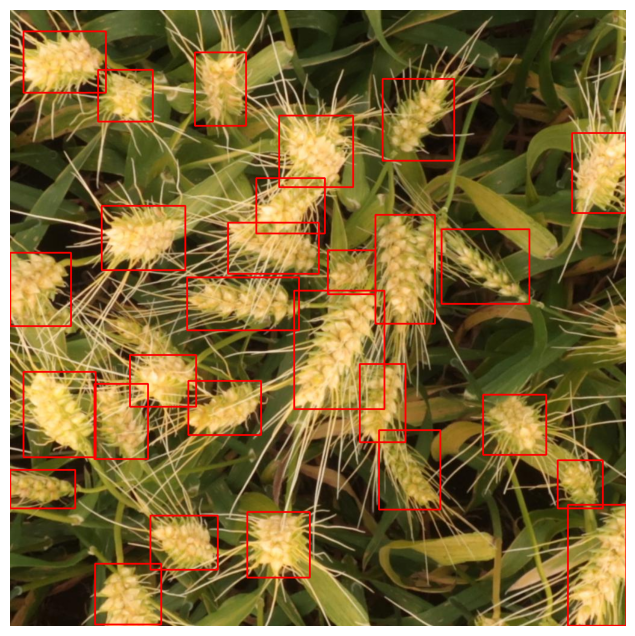

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

for box in boxes:
    cv2.rectangle(sample,
                  (box[0], box[1]),
                  (box[2], box[3]),
                  (220, 0, 0), 2)
    
ax.set_axis_off()
ax.imshow(sample)

In [13]:
test_df.to_csv('submission.csv', index=False)